installation bibliothèques

In [15]:
# 📌 Cette cellule importe les bibliothèques nécessaires pour le traitement d'image, l'entraînement du modèle et l'évaluation
import tensorflow as tf
from tqdm import tqdm
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
import re
from tqdm import tqdm
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score
from sklearn.model_selection import train_test_split
import random
import os
from tensorflow.keras.callbacks import ReduceLROnPlateau
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, BatchNormalization, Add, GlobalAveragePooling2D, Dense, Dropout, Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical


Importation CSV

In [17]:
# 📌 Cette cellule importe les bibliothèques nécessaires pour le traitement d'image, l'entraînement du modèle et l'évaluation
y_test=pd.read_csv ("test_filtered.csv", sep=",")

In [19]:
# 📌 Cette cellule importe les bibliothèques nécessaires pour le traitement d'image, l'entraînement du modèle et l'évaluation
y_val=pd.read_csv ("val_filtered.csv", sep=",")

In [21]:
# 📌 Cette cellule importe les bibliothèques nécessaires pour le traitement d'image, l'entraînement du modèle et l'évaluation
y_train = pd.read_csv ("train_filtered.csv", sep=",")

importation images

In [15]:
# 📌 Cette cellule importe les bibliothèques nécessaires pour le traitement d'image, l'entraînement du modèle et l'évaluation
ls "C:\Users\sofia\Rakuten\Nettoyage\images_bis"

 Le volume dans le lecteur C s’appelle Windows
 Le numéro de série du volume est E2D4-17F3

 Répertoire de C:\Users\sofia\Rakuten\Nettoyage\images_bis

14/03/2025  16:23    <DIR>          .
14/03/2025  15:59    <DIR>          ..
14/03/2025  15:57    <DIR>          .ipynb_checkpoints
14/03/2025  11:45        97 533 664 best_model.h5
14/03/2025  02:43            14 209 CNN.ipynb
14/03/2025  09:46           648 708 EfficientNet.ipynb
14/03/2025  02:43            52 238 mini RESNET.ipynb
14/03/2025  16:15           151 806 Processing image.ipynb
14/03/2025  00:39    <DIR>          test_bis
13/03/2025  17:56             7 753 test_filtered.csv
14/03/2025  16:03    <DIR>          train_bis
13/03/2025  17:56            78 451 train_filtered.csv
14/03/2025  16:04    <DIR>          val_bis
13/03/2025  17:56             7 737 val_filtered.csv
14/03/2025  12:40           394 487 VGG16.ipynb
14/03/2025  16:23            52 273 VGG16-Copy1.ipynb
              10 fichier(s)       98 941 326 octets
 

In [23]:

# 📂 Définition des chemins des dossiers
base_dir = r"C:\Users\sofia\Rakuten\Nettoyage\images_bis"
sub_dirs = ["train_bis", "test_bis", "val_bis"]


# 🏷 Encodage des labels
label_encoder = LabelEncoder()
y_train["prdtypecode"] = label_encoder.fit_transform(y_train["prdtypecode"])
y_test["prdtypecode"] = label_encoder.transform(y_test["prdtypecode"])
y_val["prdtypecode"] = label_encoder.transform(y_val["prdtypecode"])

# 📏 Paramètres
IMG_SIZE = (224, 224)  # Taille standard pour le CNN
BATCH_SIZE = 32  # Taille des lots

# 📥 Fonction pour charger les images avec barre de progression
def load_images_and_labels(dataframe, folder):
    images = []
    labels = []
    folder_path = os.path.join(base_dir, folder)
    
    for _, row in tqdm(dataframe.iterrows(), total=len(dataframe), desc=f"🔄 Chargement {folder}"):
        filename = f"image_{row['filename']}_product_*.jpg"  # Motif du nom de fichier
        image_files = [f for f in os.listdir(folder_path) if f.startswith(f"image_{row['filename']}_product_")]
        
        if image_files:
            img_path = os.path.join(folder_path, image_files[0])
            img = load_img(img_path, target_size=IMG_SIZE)
            img_array = img_to_array(img) / 255.0  # Normalisation
            images.append(img_array)
            labels.append(row["prdtypecode"])
    
    return np.array(images), np.array(labels)

# 📥 Chargement des images et labels avec la barre de progression
X_train, y_train = load_images_and_labels(y_train, "train_bis")
X_test, y_test = load_images_and_labels(y_test, "test_bis")
X_val, y_val = load_images_and_labels(y_val, "val_bis")

# 📌 Vérification des formes des données
print(f"Train: {X_train.shape}, Labels: {y_train.shape}")
print(f"Test: {X_test.shape}, Labels: {y_test.shape}")
print(f"Val: {X_val.shape}, Labels: {y_val.shape}")


🔄 Chargement val_bis: 100%|██████████| 500/500 [00:04<00:00, 105.99it/s]


Train: (5000, 224, 224, 3), Labels: (5000,)
Test: (500, 224, 224, 3), Labels: (500,)
Val: (500, 224, 224, 3), Labels: (500,)


Encodage Labels :

entrainement modèle 

In [25]:
# 📌 Cette cellule importe les bibliothèques nécessaires pour le traitement d'image, l'entraînement du modèle et l'évaluation
from tensorflow.keras.utils import to_categorical

NUM_CLASSES=27
# Vérifier et encoder les labels si nécessaire
if len(y_train.shape) == 1:
    y_train = to_categorical(y_train, NUM_CLASSES)
    y_val = to_categorical(y_val, NUM_CLASSES)
    y_test = to_categorical(y_test, NUM_CLASSES)


⚠️ Aucun GPU détecté, exécution sur CPU.


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 27)             │         3,483 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,929,563 (68.40 MB)

 Trainable params: 3,214,875 (12.26 MB)

...

313/313 ━━━━━━━━━━━━━━━━━━━━ 1065s 3s/step - accuracy: 0.1960 - loss: 3.0350 - val_accuracy: 0.3360 - val_loss: 2.3032 - learning_rate: 0.0010
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2782 - loss: 2.3935
Epoch 2: val_loss improved from 2.30319 to 1.98574, saving model to best_model.h5


313/313 ━━━━━━━━━━━━━━━━━━━━ 1032s 3s/step - accuracy: 0.2783 - loss: 2.3933 - val_accuracy: 0.4200 - val_loss: 1.9857 - learning_rate: 0.0010
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3152 - loss: 2.2194
Epoch 3: val_loss improved from 1.98574 to 1.93361, saving model to best_model.h5


313/313 ━━━━━━━━━━━━━━━━━━━━ 1034s 3s/step - accuracy: 0.3152 - loss: 2.2193 - val_accuracy: 0.4180 - val_loss: 1.9336 - learning_rate: 0.0010
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3532 - loss: 2.0945
Epoch 4: val_loss improved from 1.93361 to 1.88065, saving model to best_model.h5


313/313 ━━━━━━━━━━━━━━━━━━━━ 1019s 3s/step - accuracy: 0.3532 - loss: 2.0946 - val_accuracy: 0.4480 - val_loss: 1.8806 - learning_rate: 0.0010
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3324 - loss: 2.1018
Epoch 5: val_loss did not improve from 1.88065
313/313 ━━━━━━━━━━━━━━━━━━━━ 1006s 3s/step - accuracy: 0.3324 - loss: 2.1018 - val_accuracy: 0.4260 - val_loss: 1.9281 - learning_rate: 0.0010
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3621 - loss: 2.0161
Epoch 6: val_loss did not improve from 1.88065
313/313 ━━━━━━━━━━━━━━━━━━━━ 1009s 3s/step - accuracy: 0.3621 - loss: 2.0160 - val_accuracy: 0.4340 - val_loss: 1.9254 - learning_rate: 0.0010
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3490 - loss: 2.0080
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 7: val_loss did not improve from 1.88065
313/313 ━━━━━━━━━━━━━━━━━━━━ 1009s 3s/step - accuracy: 0.3491 - loss: 2.0079 - val_accuracy: 0.400

C:\Users\sofia\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\sofia\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\sofia\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
ERROR:tornado.application:Exception in c

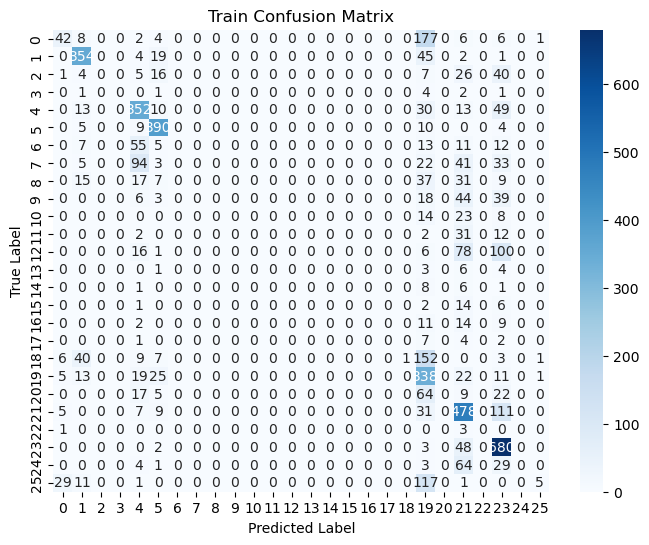

C:\Users\sofia\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\sofia\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\sofia\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
ERROR:tornado.application:Exception in c

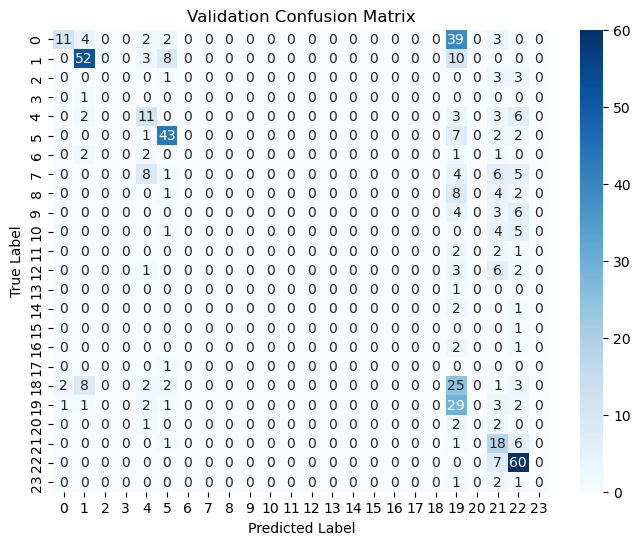

C:\Users\sofia\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\sofia\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\sofia\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
ERROR:tornado.application:Exception in c

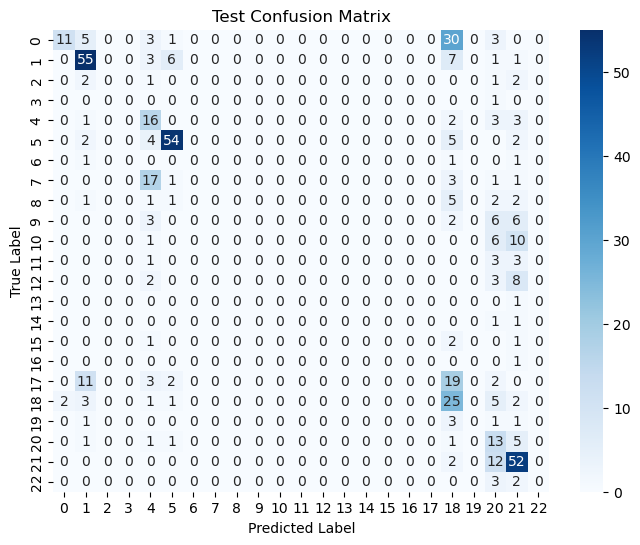

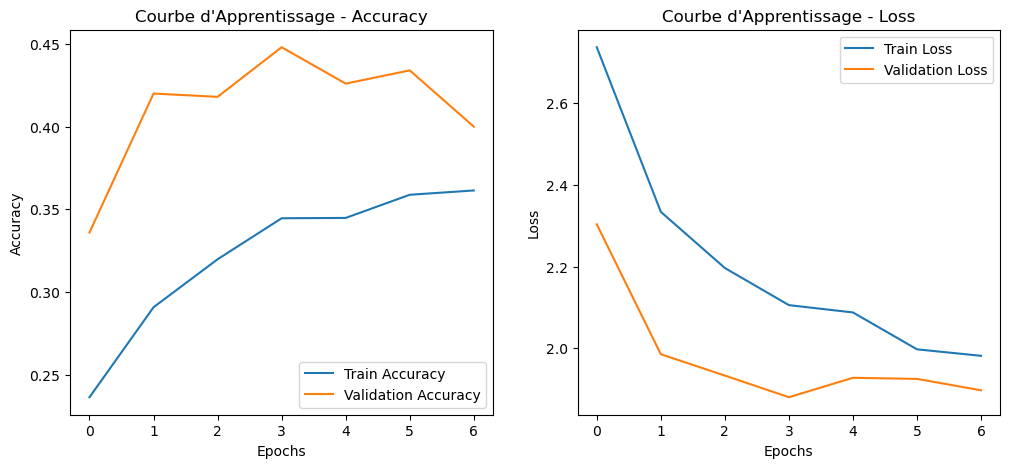

In [27]:
# 📌 Cette cellule importe les bibliothèques nécessaires pour le traitement d'image, l'entraînement du modèle et l'évaluation
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
import numpy as np
import random
import os
import tensorflow as tf

# 📌 Fixer le seed pour assurer la reproductibilité
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# 📌 Vérification de l'utilisation GPU
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("\u2705 GPU détecté et mémoire limitée")
else:
    print("\u26a0️ Aucun GPU détecté, exécution sur CPU.")


# 📌 Chargement du VGG16 pré-entraîné
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # On gèle les poids du modèle pré-entrainé

# 📌 Ajout des couches personnalisées
x = Flatten()(base_model.output)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

# 📌 Création du modèle
model = Model(inputs=base_model.input, outputs=outputs)

# 📌 Compilation du modèle
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 📌 Affichage du résumé du modèle
model.summary()

# 📌 Callbacks
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
checkpoint = ModelCheckpoint("best_model.h5", monitor='val_loss', save_best_only=True, verbose=1)

# 📌 Entraînement du modèle
history = model.fit(
    X_train, y_train, 
    epochs=10, 
    batch_size=16, 
    validation_data=(X_val, y_val), 
    callbacks=[early_stopping, lr_scheduler, checkpoint]
)

# 📌 Prédictions sur Train, Validation et Test
y_train_pred = model.predict(X_train)
y_train_pred_classes = np.argmax(y_train_pred, axis=1)
y_train_true_classes = np.argmax(y_train, axis=1)

y_val_pred = model.predict(X_val)
y_val_pred_classes = np.argmax(y_val_pred, axis=1)
y_val_true_classes = np.argmax(y_val, axis=1)

y_test_pred = model.predict(X_test)
y_test_pred_classes = np.argmax(y_test_pred, axis=1)
y_test_true_classes = np.argmax(y_test, axis=1)

# 📌 Calcul des métriques pour chaque dataset
def compute_metrics(y_true, y_pred, dataset_name):
    from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    accuracy = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')
    conf_matrix = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred)

    print(f"\n\ud83d\udcca {dataset_name} Metrics:")
    print(f"\u2705 Accuracy: {accuracy:.4f}")
    print(f"\u2705 F1-score: {f1:.4f}")
    print(f"\ud83d\udd0d Classification Report:\n{report}")

    # Matrice de confusion
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"{dataset_name} Confusion Matrix")
    plt.show()

# 📌 Affichage des métriques pour Train, Validation et Test
compute_metrics(y_train_true_classes, y_train_pred_classes, "Train")
compute_metrics(y_val_true_classes, y_val_pred_classes, "Validation")
compute_metrics(y_test_true_classes, y_test_pred_classes, "Test")

# 📌 Courbes d'entraînement
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Courbe d\'Apprentissage - Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Courbe d\'Apprentissage - Loss')

plt.show()




In [8]:
# 📌 Cette cellule importe les bibliothèques nécessaires pour le traitement d'image, l'entraînement du modèle et l'évaluation
import psutil

def check_ram():
    """Affiche l'utilisation de la mémoire RAM."""
    ram = psutil.virtual_memory()
    print(f"🔍 Mémoire RAM utilisée : {ram.used / (1024 ** 3):.2f} GB / {ram.total / (1024 ** 3):.2f} GB")
    print(f"📌 Pourcentage utilisé : {ram.percent}%")

# 📌 Exécuter la fonction pour voir la mémoire actuelle
check_ram()


🔍 Mémoire RAM utilisée : 7.14 GB / 7.79 GB
📌 Pourcentage utilisé : 91.6%


In [29]:
# 📌 Cette cellule importe les bibliothèques nécessaires pour le traitement d'image, l'entraînement du modèle et l'évaluation
def compute_metrics(y_true, y_pred, dataset_name):
    accuracy = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')
    conf_matrix = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred)

    print(f"\n📊 {dataset_name} Metrics:")
    print(f"✅ Accuracy: {accuracy:.4f}")
    print(f"✅ F1-score: {f1:.4f}")
    print(f"🔍 Classification Report:\n{report}")

# 📌 Affichage des métriques pour Train, Validation et Test
compute_metrics(y_train_true_classes, y_train_pred_classes, "Train")
compute_metrics(y_val_true_classes, y_val_pred_classes, "Validation")
compute_metrics(y_test_true_classes, y_test_pred_classes, "Test")


📊 Train Metrics:
✅ Accuracy: 0.5280
✅ F1-score: 0.4290
🔍 Classification Report:
              precision    recall  f1-score   support

           0       0.47      0.17      0.25       246
           1       0.74      0.83      0.79       425
           2       0.00      0.00      0.00        99
           3       0.00      0.00      0.00         9
           4       0.56      0.75      0.65       467
           5       0.77      0.93      0.84       418
           6       0.00      0.00      0.00       103
           7       0.00      0.00      0.00       198
           8       0.00      0.00      0.00       116
           9       0.00      0.00      0.00       110
          10       0.00      0.00      0.00        45
          11       0.00      0.00      0.00        47
          12       0.00      0.00      0.00       201
          13       0.00      0.00      0.00        14
          14       0.00      0.00      0.00        16
          15       0.00      0.00      0.00        23


C:\Users\sofia\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\sofia\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\sofia\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\sofia\anaconda3\Lib\site-packag